In [9]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
from astropy import units as u
import os, sys, json

import eazy
import eazy.hdf5
import h5py

# quiet numpy/astropy warnings
import warnings
from astropy.utils.exceptions import AstropyWarning
np.seterr(all='ignore')
warnings.simplefilter('ignore', category=AstropyWarning)

field = 'goodss'
n_proc = 1

print('\n==========================================')
print(f'Running EAZY in {field}, n_proc = {n_proc}')
print('==========================================\n')

try:
    print('EAZYCODE = '+os.getenv('EAZYCODE'))
except:
    pass

if not os.path.exists('templates'):
    eazy.symlink_eazy_inputs() 

'''
Define path and how to read data for each field
'''
'''
Read input photometric catalog and parse double header
'''
print(f'Loading input photometry in {field}')
# Assuming the file in the directory is the .cat file shown in the image
catFn = './GOODS-S_photometry.cat'


Running EAZY in goodss, n_proc = 1

Loading input photometry in goodss


In [10]:
cat_phot = Table.read(catFn, format='ascii.commented_header')
idx = np.where(cat_phot['id']==44004)
cat_phot = cat_phot[idx]
cat_phot

id,f_nircam_f090w,e_nircam_f090w,f_wfc3-ir_f105w,e_wfc3-ir_f105w,f_wfc3-ir_f110w,e_wfc3-ir_f110w,f_nircam_f115w,e_nircam_f115w,f_niriss_f115w,e_niriss_f115w,f_wfc3-ir_f125w,e_wfc3-ir_f125w,f_wfc3-ir_f140w,e_wfc3-ir_f140w,f_nircam_f150w,e_nircam_f150w,f_niriss_f150w,e_niriss_f150w,f_wfc3-ir_f160w,e_wfc3-ir_f160w,f_nircam_f182m,e_nircam_f182m,f_nircam_f200w,e_nircam_f200w,f_niriss_f200w,e_niriss_f200w,f_nircam_f210m,e_nircam_f210m,f_nircam_f277w,e_nircam_f277w,f_nircam_f335m,e_nircam_f335m,f_wfc3-uvis_f350lp,e_wfc3-uvis_f350lp,f_nircam_f356w,e_nircam_f356w,f_nircam_f410m,e_nircam_f410m,f_nircam_f430m,e_nircam_f430m,f_acs_f435w,e_acs_f435w,f_nircam_f444w,e_nircam_f444w,f_nircam_f460m,e_nircam_f460m,f_acs_f475w,e_acs_f475w,f_nircam_f480m,e_nircam_f480m,f_acs_f606w,e_acs_f606w,f_wfc3-uvis_f606w,e_wfc3-uvis_f606w,f_acs_f775w,e_acs_f775w,f_acs_f814w,e_acs_f814w,f_wfc3-uvis_f814w,e_wfc3-uvis_f814w,f_acs_f850lp,e_acs_f850lp,f_wfc3-uvis_f850lp,e_wfc3-uvis_f850lp,z_spec
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
44004,0.0419713,0.0008655044,0.03981832,0.003058597,-99.0,10000000000.0,0.05493671,0.0007796168,-99.0,10000000000.0,0.03812507,0.003521445,0.02870368,0.01411814,0.05049409,0.000814524,-99.0,10000000000.0,0.04039758,0.004272241,0.03862503,0.002667656,0.04556939,0.0008299526,-99.0,10000000000.0,0.03818528,0.003275857,0.0429042,0.0006174296,0.09331119,0.000978911,0.001237569,0.002260043,0.05803317,0.0007256833,0.0295947,0.0007929754,-99.0,10000000000.0,0.001721314,0.002173075,0.04471809,0.0007630191,-99.0,10000000000.0,-99.0,10000000000.0,-99.0,10000000000.0,-0.0009612276,0.002547359,-99.0,10000000000.0,0.008500915,0.00382914,0.0141157,0.002287877,-99.0,10000000000.0,0.04375438,0.004703552,-99.0,10000000000.0,5.8289


In [11]:
FILTER_TRANS = {
    'ACS_F435W':233,
    'ACS_F606W':236,
    'ACS_F775W':238,
    'ACS_F814W':239,
    'ACS_F850LP':240,
    'NRC_F070W':362,
    'NRC_F090W':363,
    'NRC_F115W':364,
    'NRC_F140M':368,
    'NRC_F150W':365,
    'NRC_F162M':369,
    'NRC_F182M':370,
    'NRC_F200W':366,
    'NRC_F210M':371,
    'NRC_F250M':379,
    'NRC_F277W':375,
    'NRC_F300M':380,
    'NRC_F335M':381,
    'NRC_F356W':376,
    'NRC_F360M':382,
    'NRC_F410M':383,
    'NRC_F430M':384,
    'NRC_F444W':377,
    'NRC_F460M':385,
    'NRC_F480M':386,

}

fp = open(f'./{field}_zphot.translate', 'w')

for filt in FILTER_TRANS.keys():
    instr,band = filt.split('_')
    if instr == 'ACS':
        colname = f'f_acs_{band.lower()}'
    elif instr == 'NRC':
        colname = f'f_nircam_{band.lower()}'
    fp.write(f"{colname} F{FILTER_TRANS[filt]}\n")
    fp.write(f"{colname.replace('f_', 'e_')} E{FILTER_TRANS[filt]}\n")
fp.close()

In [12]:
# 5% error floor and save to fits
rel_err = 0.05
for col in cat_phot.colnames:
    if col.startswith('f_'):
        err_col = col.replace('f_', 'e_')
        cat_phot[err_col] = np.sqrt(cat_phot[err_col]**2 + (cat_phot[col]*rel_err)**2)
cat_phot.write(f'./{field}_input_phot.fits', overwrite=True)

In [17]:

# Galactic extinction from https://irsa.ipac.caltech.edu/applications/DUST/
EBV = {'abell2744':0.0114,
    'egs':0.0083,
    'cosmos':0.0146, 
    'goodss':0.0069, 
    'uds':0.0185, 
    'goodsn':0.0097}

'''
Run EAZY
'''
eazyInputDir = './'
eazyOutputDir = './'
print(f'Start EAZY in {field}')
params = {}
params['CATALOG_FILE'] = f'{eazyInputDir}/{field}_input_phot.fits'
params['OUTPUT_DIRECTORY'] = f"{eazyOutputDir}"
params['MAIN_OUTPUT_FILE'] = f'{field}_photoz.out'
params['MW_EBV'] = EBV[field]
params['CAT_HAS_EXTCORR'] = False

params['APPLY_PRIOR'] = 'n' 
params['Z_MIN'] = 0.01
params['Z_MAX'] = 22
params['Z_STEP'] = 0.01
params['PRIOR_ABZP'] = 31.4

params['TEMPLATES_FILE'] = 'templates.param'
# params['TEMPLATES_FILE'] = 'templates/fsps_full/fsps_QSF_12_v3.param'
params['TEMP_ERR_FILE'] = 'templates/TEMPLATE_ERROR.v2.0.zfourge'

params['VERBOSITY'] = 1

ez = eazy.photoz.PhotoZ(param_file=None,
                              translate_file=f'{eazyInputDir}/{field}_zphot.translate',
                              zeropoint_file=None, params=params,
                              load_prior=True, load_products=False)

ez.fit_catalog(n_proc=n_proc)

Start EAZY in goodss
Read default param file: /lustre/astro/zychen/code/miniforge3/envs/msaexp/lib/python3.12/site-packages/eazy/data/zphot.param.default
Read CATALOG_FILE: .//goodss_input_phot.fits
   >>> NOBJ = 1
f_acs_f435w e_acs_f435w (233): hst/ACS_update_sep07/wfc_f435w_t81.dat
f_acs_f606w e_acs_f606w (236): hst/ACS_update_sep07/wfc_f606w_t81.dat
f_acs_f775w e_acs_f775w (238): hst/ACS_update_sep07/wfc_f775w_t81.dat
f_acs_f814w e_acs_f814w (239): hst/ACS_update_sep07/wfc_f814w_t81.dat
f_acs_f850lp e_acs_f850lp (240): hst/ACS_update_sep07/wfc_f850lp_t81.dat
f_nircam_f090w e_nircam_f090w (363): jwst_nircam_f090w
f_nircam_f115w e_nircam_f115w (364): jwst_nircam_f115w
f_nircam_f150w e_nircam_f150w (365): jwst_nircam_f150w
f_nircam_f182m e_nircam_f182m (370): jwst_nircam_f182m
f_nircam_f200w e_nircam_f200w (366): jwst_nircam_f200w
f_nircam_f210m e_nircam_f210m (371): jwst_nircam_f210m
f_nircam_f277w e_nircam_f277w (375): jwst_nircam_f277w
f_nircam_f335m e_nircam_f335m (381): jwst_nirca

100%|██████████| 16/16 [00:02<00:00,  5.89it/s]


Template   0: eazy_v1.1_sed5.sed (NZ=1).
Template   1: eazy_v1.1_sed4.sed (NZ=1).
Template   2: eazy_v1.1_sed3.sed (NZ=1).
Template   3: eazy_v1.1_sed2.sed (NZ=1).
Template   4: eazy_v1.1_sed1.sed (NZ=1).
Template   5: eazy_v1.1_sed7.sed (NZ=1).
Template   6: erb2010_highEW.sed (NZ=1).
Template   7: c09_del_8.6_z_0.019_chab_age09.40_av2.0.sed (NZ=1).
Template   8: JADES_v1.0_1.sed (NZ=1).
Template   9: JADES_v1.0_2.sed (NZ=1).
Template  10: JADES_v1.0_3.sed (NZ=1).
Template  11: JADES_v1.0_4.sed (NZ=1).
Template  12: JADES_v1.0_5.sed (NZ=1).
Template  13: JADES_v1.0_6.sed (NZ=1).
Template  14: JADES_v1.0_7.sed (NZ=1).
Template  15: eazy_v1.1_sed6.sed (NZ=1).
Process templates: 7.457 s


313it [00:00, 33433.09it/s]
100%|██████████| 313/313 [00:00<00:00, 2369.03it/s]


Compute best fits
fit_best: 0.0 s (n_proc=1,  NOBJ=1)
Fit 0.2 s (n_proc=1, NOBJ=1)


(<Figure size 800x400 with 2 Axes>,
 OrderedDict([('ix', 0),
              ('id', 44004),
              ('z', 6.011466),
              ('z_spec', 5.8289),
              ('pivot',
               array([ 4318.82810211,  5920.81887956,  7692.30432928,  8056.87950929,
                       9032.68320402,  9022.92219271, 11543.00930164, 15007.45492632,
                      18452.20651021, 19886.47814337, 20955.30780847, 27623.47466385,
                      33623.02517333, 35682.2778744 , 40820.73020365, 42812.86944883,
                      44037.1390651 , 46302.41760368, 48155.79518006])),
              ('model',
               array([1.34035981e-12, 6.59318519e-07, 4.60785372e-06, 1.82013197e-05,
                      4.93716904e-05, 4.34735980e-05, 5.21377404e-05, 4.78318317e-05,
                      4.23509037e-05, 4.08555588e-05, 3.96509182e-05, 4.66240527e-05,
                      8.90256209e-05, 5.94768692e-05, 2.98717491e-05, 2.86697403e-05,
                      4.37621247e-05

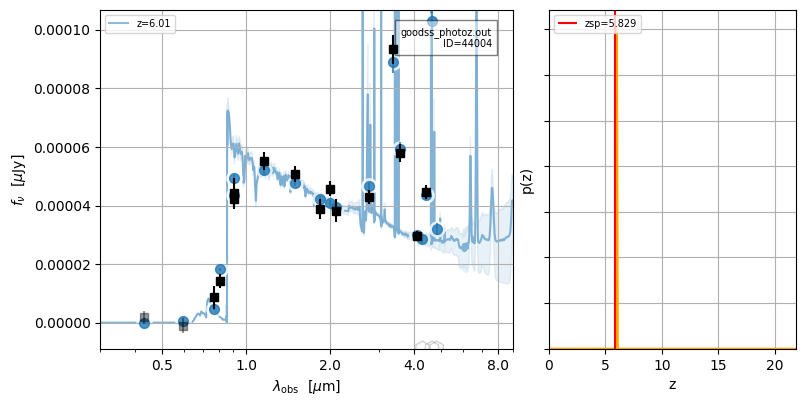

In [18]:
ez.show_fit(44004, show_fnu=1)